# Bitcoin Price Prediction — Model Comparison

## Business Context
Bitcoin (BTC) is the world's leading cryptocurrency and one of the most traded financial assets globally. Its price is driven by market sentiment, adoption trends, regulatory news, and macro-economic conditions. Accurate daily price prediction helps traders optimise entry/exit decisions, risk management systems automate exposure limits, and investment platforms provide data-driven recommendations.

This notebook implements a full end-to-end ML pipeline **comparing three models** on the same dataset:
1. **Linear Regression** — simple baseline using the last 100 days as flat features
2. **Random Forest** — tree-based ensemble that captures non-linear patterns
3. **LSTM Neural Network** — deep learning model designed for sequential time series

Pipeline steps:
1. **Data retrieval** — historical Bitcoin/USD prices (`BTC-USD`) via Yahoo Finance (`yfinance`)
2. **EDA** — exploratory analysis and moving-average visualisations
3. **Preprocessing** — MinMax scaling + sliding-window sequence generation
4. **Modelling** — train and track all three models with MLflow
5. **Evaluation** — MAE, RMSE, R² comparison table and plots

## Setup

Install the project dependencies from `requirements.txt` and run this notebook in a virtual environment. Run from terminal:

```powershell
python -m pip install -r requirements.txt
```

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from datetime import date
from IPython.display import display

import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import joblib
import os
import mlflow
import mlflow.keras

# ── Global plot style — pastel palette (improved contrast) ────────
PALETTE = {
    'close':  '#8A79C9',   # darker lavender for better visibility
    'actual': '#556B7B',   # muted slate (darker for readability)
    'lr':     '#6495ED',   # cornflowerblue (Linear Regression)
    'rf':     '#7B68EE',   # mediumslateblue (Random Forest)
    'lstm':   '#9400D3',   # darkviolet (LSTM)
    'ma100':  '#8B5CF6',   # lavender (slightly deeper)
    'ma200':  '#C7B9FF',   # light lavender
    'loss':   '#2563EB',   # stronger blue for loss curves
    'val':    '#8B5CF6',   # lavender
    'bars':   ['#6495ED', '#7B68EE', '#9400D3'],  # cornflower → mediumslate → darkviolet
    'grid':   '#E6EEF6',
    'hl':     '#E6F0FF',   # table highlight
}
plt.rcParams.update({
    'axes.facecolor':  '#FEFEFF',
    'figure.facecolor': 'white',
    'grid.color':      PALETTE['grid'],
    'grid.linestyle':  '--',
})

print(f"TensorFlow: {tf.__version__}  |  MLflow: {mlflow.__version__}")

TensorFlow: 2.21.0  |  MLflow: 3.11.1


## Step 1 — Data Acquisition

Connect to Yahoo Finance and download daily Bitcoin/USD price data (`BTC-USD`) from 2015 to today.

In [2]:
# Parameters and data loader
START = '2015-01-01'
TODAY = date.today().strftime('%Y-%m-%d')
# Bitcoin/USD daily prices from Yahoo Finance
# Alternatives: 'BTC-USDT' (Binance via ccxt), 'GBTC' (ETF proxy)
TICKER = 'BTC-USD'

def load_data(ticker, start=START, end=TODAY, interval='1d'):
    df = yf.download(ticker, start=start, end=end, interval=interval)
    df.reset_index(inplace=True)
    return df

# Fetch data
df = load_data(TICKER)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
0,2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
1,2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2,2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400
3,2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100
4,2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800


In [3]:
# --- EDA ---
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescriptive statistics:")
df[['Open','High','Low','Close','Volume']].describe()

Shape: (4127, 6)

Column types:
Price   Ticker 
Date               datetime64[ns]
Close   BTC-USD           float64
High    BTC-USD           float64
Low     BTC-USD           float64
Open    BTC-USD           float64
Volume  BTC-USD             int64
dtype: object

Missing values:
Price   Ticker 
Date               0
Close   BTC-USD    0
High    BTC-USD    0
Low     BTC-USD    0
Open    BTC-USD    0
Volume  BTC-USD    0
dtype: int64

Descriptive statistics:


Price,Open,High,Low,Close,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,4127.000000,4127.000000,4127.000000,4127.000000,4.127000e+03
mean,28801.548277,29377.183560,28189.862328,28818.324036,2.273854e+10
std,32318.215032,32866.070892,31727.639784,32322.109661,2.301548e+10
min,176.897003,211.731003,171.509995,178.102997,7.860650e+06
25%,3854.222778,3926.743408,3764.942139,3857.507568,2.932690e+09
50%,11881.647461,12144.623047,11604.599609,11892.803711,1.837228e+10
75%,46153.265625,47218.062500,44468.998047,46192.458984,3.469939e+10
max,124752.140625,126198.070312,123196.046875,124752.531250,3.509679e+11


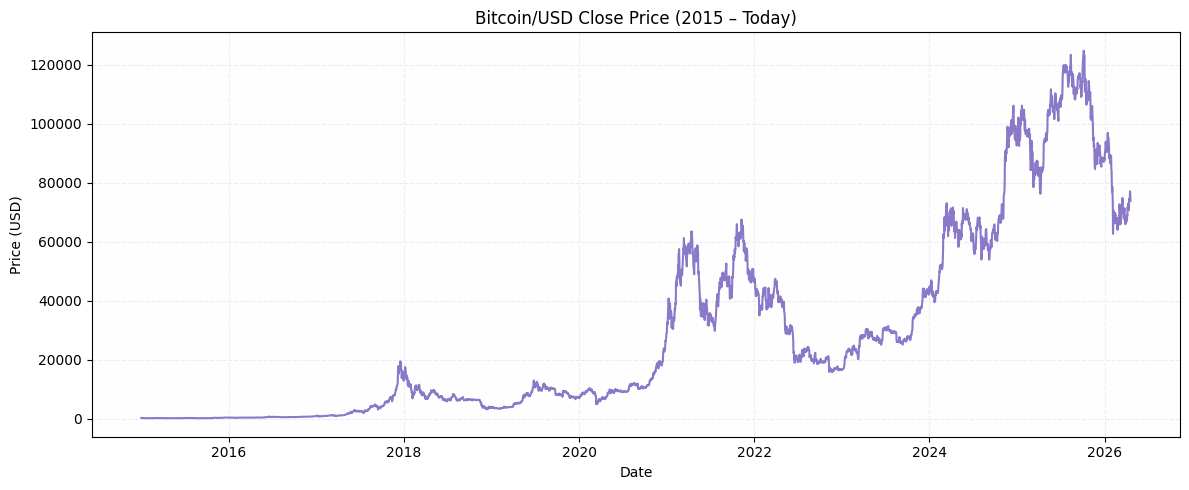

In [4]:
# Quick visualization of Close price
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], color=PALETTE['close'], linewidth=1.5)
plt.title('Bitcoin/USD Close Price (2015 – Today)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

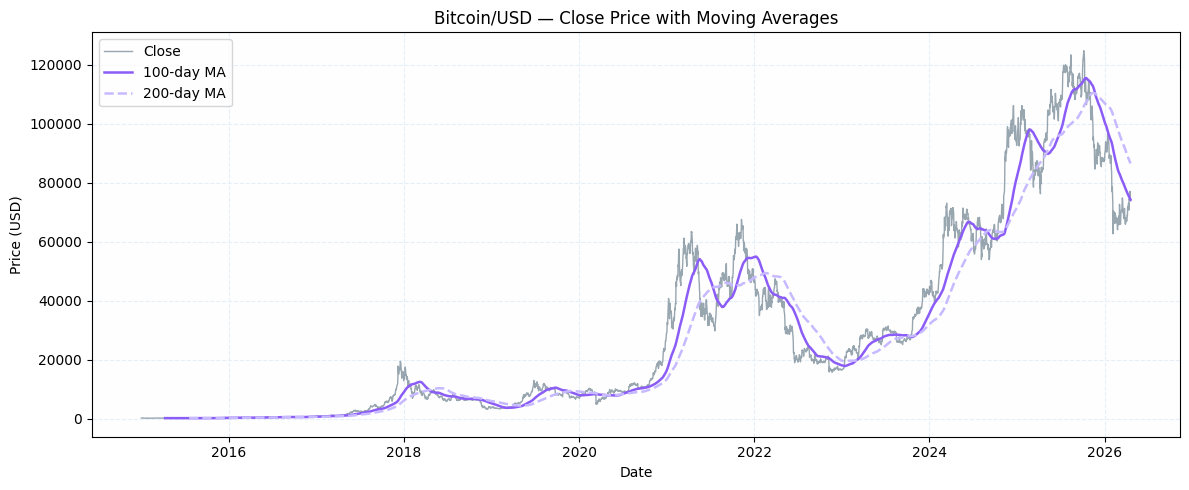

In [5]:
# Moving averages — 100 day and 200 day
ma100 = df['Close'].rolling(100).mean()
ma200 = df['Close'].rolling(200).mean()

plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], label='Close',       color=PALETTE['actual'], alpha=0.6, linewidth=1)
plt.plot(df['Date'], ma100,       label='100-day MA',  color=PALETTE['ma100'],  linewidth=1.8)
plt.plot(df['Date'], ma200,       label='200-day MA',  color=PALETTE['ma200'],  linewidth=1.8, linestyle='--')
plt.title('Bitcoin/USD — Close Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 2 — Preprocessing

- Keep only the `Close` price column
- Normalise with **MinMaxScaler** (0–1 range)  
- Create overlapping sequences of length 100 (each sample = 100 past days → predict next day)  
- Train/test split: **70% / 30%** (chronological — no shuffling)

In [6]:
# Preprocessing: keep Close column and split train/test (70/30)
data = df[['Close']].copy()
data.dropna(inplace=True)
train = data[:int(len(data) * 0.7)]
test  = data[int(len(data) * 0.7):]

scaler = MinMaxScaler(feature_range=(0, 1))
train_vals = scaler.fit_transform(train)
test_vals  = scaler.transform(test)

# Helper to create overlapping sliding-window sequences
def create_sequences(values, seq_len=100):
    X, y = [], []
    for i in range(seq_len, len(values)):
        X.append(values[i - seq_len:i, 0])
        y.append(values[i, 0])
    return np.array(X), np.array(y)

SEQ_LEN = 100
x_train, y_train = create_sequences(train_vals, SEQ_LEN)
x_test,  y_test  = create_sequences(
    np.concatenate([train_vals[-SEQ_LEN:], test_vals], axis=0), SEQ_LEN
)

# ── Flat (2-D) arrays for Linear Regression & Random Forest ──────────
x_train_2d = x_train.copy()   # shape: (samples, SEQ_LEN)
x_test_2d  = x_test.copy()

# ── 3-D arrays for LSTM: (samples, timesteps, features) ─────────────
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test  = x_test.reshape((x_test.shape[0],  x_test.shape[1],  1))

# Inverse-transform labels once — reused by all three model evaluations
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

print(f"3-D (LSTM)  — train: {x_train.shape}  |  test: {x_test.shape}")
print(f"2-D (LR/RF) — train: {x_train_2d.shape}  |  test: {x_test_2d.shape}")

3-D (LSTM)  — train: (2788, 100, 1)  |  test: (1239, 100, 1)
2-D (LR/RF) — train: (2788, 100)  |  test: (1239, 100)


In [7]:
# ── SHORTCUT: Load saved models from disk (skip training cells) ───────
# Run this cell instead of the three training cells below if models are
# already trained and saved. Then jump directly to the evaluation cell.
import tensorflow as tf

REPO_ROOT   = os.path.dirname(os.getcwd())
MODELS_DIR  = os.path.join(REPO_ROOT, 'models')

_lr_path    = os.path.join(MODELS_DIR, 'lr_model.save')
_rf_path    = os.path.join(MODELS_DIR, 'rf_model.save')
_lstm_path  = os.path.join(MODELS_DIR, 'keras_model.h5')
_scaler_path = os.path.join(MODELS_DIR, 'scaler.save')

_missing = [p for p in [_lr_path, _rf_path, _lstm_path, _scaler_path] if not os.path.exists(p)]
if _missing:
    print("⚠ Some artifacts not found — run the training cells first:")
    for p in _missing:
        print(f"   {p}")
else:
    lr_model  = joblib.load(_lr_path)
    rf_model  = joblib.load(_rf_path)
    model     = tf.keras.models.load_model(_lstm_path)
    scaler    = joblib.load(_scaler_path)

    lr_pred     = lr_model.predict(x_test_2d)
    lr_pred_inv = scaler.inverse_transform(lr_pred.reshape(-1, 1))
    lr_mae      = mean_absolute_error(y_test_inv, lr_pred_inv)
    lr_rmse     = float(np.sqrt(np.mean((y_test_inv - lr_pred_inv) ** 2)))
    lr_r2       = r2_score(y_test_inv, lr_pred_inv)

    rf_pred     = rf_model.predict(x_test_2d)
    rf_pred_inv = scaler.inverse_transform(rf_pred.reshape(-1, 1))
    rf_mae      = mean_absolute_error(y_test_inv, rf_pred_inv)
    rf_rmse     = float(np.sqrt(np.mean((y_test_inv - rf_pred_inv) ** 2)))
    rf_r2       = r2_score(y_test_inv, rf_pred_inv)

    lstm_pred     = model.predict(x_test)
    lstm_pred_inv = scaler.inverse_transform(lstm_pred)
    lstm_mae      = mean_absolute_error(y_test_inv, lstm_pred_inv)
    lstm_rmse     = float(np.sqrt(np.mean((y_test_inv - lstm_pred_inv) ** 2)))
    lstm_r2       = r2_score(y_test_inv, lstm_pred_inv)

    print("✓ All models loaded from disk. Scroll down to the evaluation cell to regenerate plots.")

39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
✓ All models loaded from disk. Scroll down to the evaluation cell to regenerate plots.


## Step 3 — Build & Train Models

Three models are trained on the same preprocessed data and each run is logged in MLflow under the **`bitcoin-price-prediction`** experiment:

| Model | Type | Input shape |
|-------|------|-------------|
| **Linear Regression** | Parametric baseline | `(samples, 100)` — flat |
| **Random Forest** | Tree-based ensemble | `(samples, 100)` — flat |
| **LSTM** | Deep learning sequence model | `(samples, 100, 1)` — 3-D |

In [8]:
# ── Model A: Linear Regression ───────────────────────────────────────
# Set up paths and MLflow tracking once (used by all three model cells)
REPO_ROOT  = os.path.dirname(os.getcwd())
MLFLOW_DIR = os.path.join(REPO_ROOT, 'mlflow')
os.makedirs(MLFLOW_DIR, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{os.path.join(MLFLOW_DIR, 'mlflow.db')}")
mlflow.set_experiment("bitcoin-price-prediction")

lr_model = LinearRegression()

with mlflow.start_run(run_name="linear-regression"):
    mlflow.log_param("model",   "LinearRegression")
    mlflow.log_param("ticker",  TICKER)
    mlflow.log_param("seq_len", SEQ_LEN)

    lr_model.fit(x_train_2d, y_train)

    lr_pred     = lr_model.predict(x_test_2d)
    lr_pred_inv = scaler.inverse_transform(lr_pred.reshape(-1, 1))

    lr_mae  = mean_absolute_error(y_test_inv, lr_pred_inv)
    lr_rmse = float(np.sqrt(np.mean((y_test_inv - lr_pred_inv) ** 2)))
    lr_r2   = r2_score(y_test_inv, lr_pred_inv)

    mlflow.log_metric("mae_usd",  lr_mae)
    mlflow.log_metric("rmse_usd", lr_rmse)
    mlflow.log_metric("r2",       lr_r2)

    joblib.dump(lr_model, os.path.join(REPO_ROOT, 'models', 'lr_model.save'))

print(f"Linear Regression  →  MAE: ${lr_mae:,.0f}  |  RMSE: ${lr_rmse:,.0f}  |  R²: {lr_r2:.4f}")

2026/04/20 20:56:47 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/20 20:56:47 INFO mlflow.store.db.utils: Updating database tables
2026/04/20 20:56:48 INFO mlflow.tracking.fluent: Experiment with name 'bitcoin-price-prediction' does not exist. Creating a new experiment.


Linear Regression  →  MAE: $1,234  |  RMSE: $1,822  |  R²: 0.9966


In [9]:
# ── Model B: Random Forest ────────────────────────────────────────────
RF_N_ESTIMATORS = 100
rf_model = RandomForestRegressor(n_estimators=RF_N_ESTIMATORS, n_jobs=-1, random_state=42)

with mlflow.start_run(run_name="random-forest"):
    mlflow.log_param("model",         "RandomForestRegressor")
    mlflow.log_param("ticker",        TICKER)
    mlflow.log_param("seq_len",       SEQ_LEN)
    mlflow.log_param("n_estimators",  RF_N_ESTIMATORS)

    rf_model.fit(x_train_2d, y_train)

    rf_pred     = rf_model.predict(x_test_2d)
    rf_pred_inv = scaler.inverse_transform(rf_pred.reshape(-1, 1))

    rf_mae  = mean_absolute_error(y_test_inv, rf_pred_inv)
    rf_rmse = float(np.sqrt(np.mean((y_test_inv - rf_pred_inv) ** 2)))
    rf_r2   = r2_score(y_test_inv, rf_pred_inv)

    mlflow.log_metric("mae_usd",  rf_mae)
    mlflow.log_metric("rmse_usd", rf_rmse)
    mlflow.log_metric("r2",       rf_r2)

    joblib.dump(rf_model, os.path.join(REPO_ROOT, 'models', 'rf_model.save'))

print(f"Random Forest      →  MAE: ${rf_mae:,.0f}  |  RMSE: ${rf_rmse:,.0f}  |  R²: {rf_r2:.4f}")

Random Forest      →  MAE: $14,499  |  RMSE: $22,972  |  R²: 0.4599


In [10]:
# Build a simple LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))
model.add(LSTM(120, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

c:\Users\User\Desktop\Ironhack-DS-AI\capstone-ml-on-cloud\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ── Model C: LSTM Neural Network ──────────────────────────────────────
EPOCHS     = 50
BATCH_SIZE = 32

MODELS_DIR  = os.path.join(REPO_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)
model_path  = os.path.join(MODELS_DIR, 'keras_model.h5')
scaler_path = os.path.join(MODELS_DIR, 'scaler.save')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

with mlflow.start_run(run_name="lstm-btc-usd"):
    mlflow.log_param("model",      "LSTM")
    mlflow.log_param("ticker",     TICKER)
    mlflow.log_param("seq_len",    SEQ_LEN)
    mlflow.log_param("epochs_max", EPOCHS)
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("train_size", len(x_train))
    mlflow.log_param("test_size",  len(x_test))

    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    model.save(model_path)
    joblib.dump(scaler, scaler_path)

    mlflow.keras.log_model(model, artifact_path="lstm_model")
    mlflow.log_artifact(scaler_path)

    best = early_stop.stopped_epoch - early_stop.patience + 1 if early_stop.stopped_epoch else EPOCHS
    print(f"Stopped at epoch : {best}")
    print(f"Model saved to   : {model_path}")
    print(f"MLflow tracking  : {mlflow.get_tracking_uri()}")

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - loss: 0.0192 - val_loss: 0.0023
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 0.0064 - val_loss: 0.0028
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - loss: 0.0049 - val_loss: 0.0036
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - loss: 0.0041 - val_loss: 0.0042
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 0.0046 - val_loss: 0.0062
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0038 - val_loss: 0.0021
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0041 - val_loss: 0.0032
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0031 - val_loss: 0.0093
Epoch 9/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0038 - val_loss: 0.0019
Epoch 10/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.0032 - val_loss: 0.0018
Epoch 11/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.0034 - val_loss: 0.0045
Epoch 12/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.

2026/04/20 21:00:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 21:00:56 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Stopped at epoch : 27
Model saved to   : c:\Users\User\Desktop\Ironhack-DS-AI\capstone-ml-on-cloud\models\keras_model.h5
MLflow tracking  : sqlite:///c:\Users\User\Desktop\Ironhack-DS-AI\capstone-ml-on-cloud\mlflow\mlflow.db


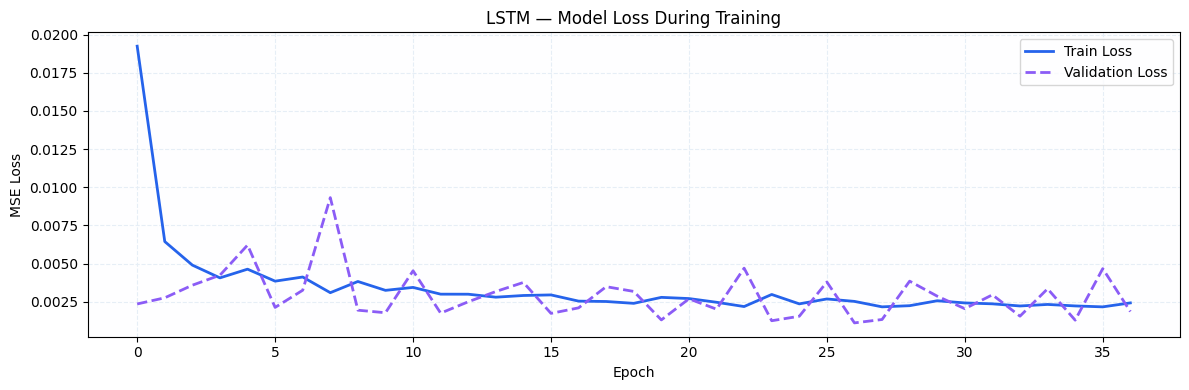

In [12]:
# Training and validation loss curves
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'],     label='Train Loss',      color=PALETTE['loss'], linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color=PALETTE['val'],  linewidth=2, linestyle='--')
plt.title('LSTM — Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 4 — Model Comparison

Evaluate all three models on the **same held-out 30% test set** and compare:
- **MAE** (Mean Absolute Error in USD) — average absolute deviation
- **RMSE** (Root Mean Squared Error in USD) — penalises large errors more
- **R²** — proportion of price variance explained (1.0 = perfect; higher is better)
- **MAE %** — MAE as a percentage of mean test price

39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step


,MAE (USD),RMSE (USD),R²,MAE %
Model,,,,
Linear Regression,"$1,234","$1,822",0.9966,1.90%
Random Forest,"$14,499","$22,972",0.4599,22.29%
LSTM,"$10,425","$14,572",0.7826,16.03%


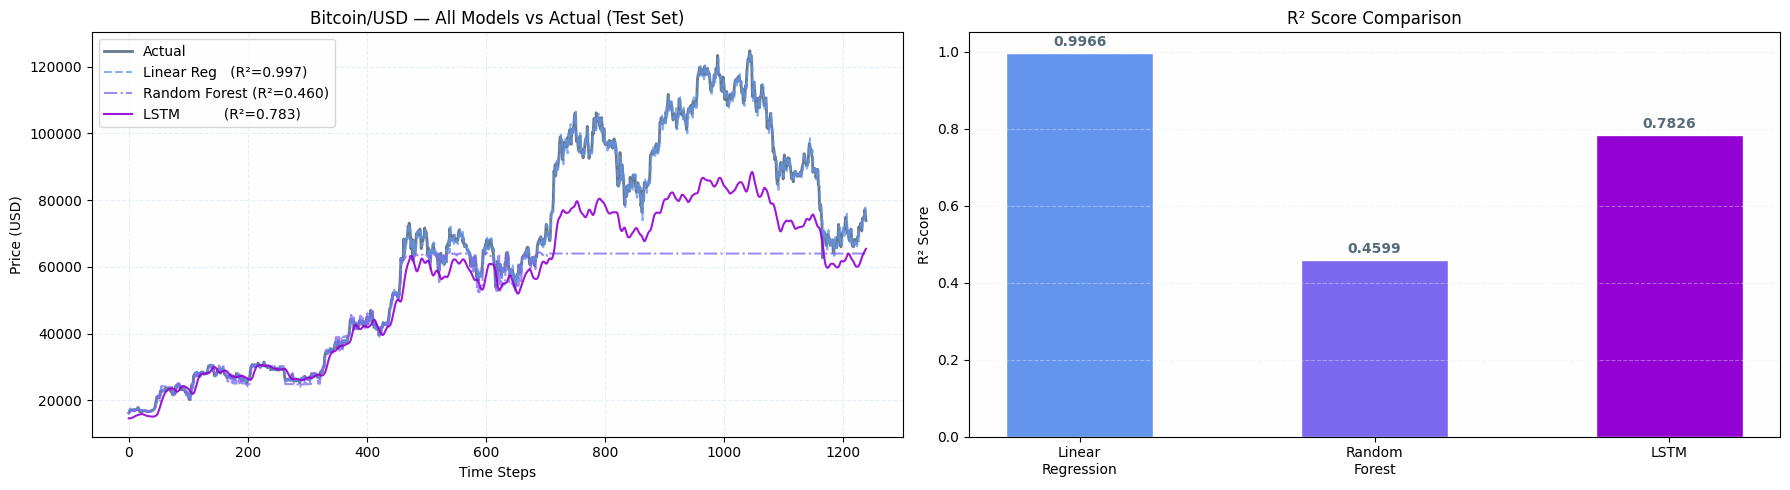

In [13]:
# ── LSTM predictions on the test set ─────────────────────────────────
lstm_pred     = model.predict(x_test)
lstm_pred_inv = scaler.inverse_transform(lstm_pred)

lstm_mae  = mean_absolute_error(y_test_inv, lstm_pred_inv)
lstm_rmse = float(np.sqrt(np.mean((y_test_inv - lstm_pred_inv) ** 2)))
lstm_r2   = r2_score(y_test_inv, lstm_pred_inv)

# Log LSTM metrics into its MLflow run
try:
    runs = mlflow.search_runs(filter_string="tags.`mlflow.runName` = 'lstm-btc-usd'",
                              order_by=["start_time DESC"])
    if not runs.empty:
        with mlflow.start_run(run_id=runs.iloc[0].run_id):
            mlflow.log_metric("mae_usd",  lstm_mae)
            mlflow.log_metric("rmse_usd", lstm_rmse)
            mlflow.log_metric("r2",       lstm_r2)
            mlflow.log_metric("mae_pct",  (lstm_mae / float(np.mean(y_test_inv))) * 100)
except Exception:
    pass  # metrics printed below regardless

# ── Comparison table ──────────────────────────────────────────────────
mean_price = float(np.mean(y_test_inv))

results = pd.DataFrame({
    'Model':      ['Linear Regression', 'Random Forest', 'LSTM'],
    'MAE (USD)':  [lr_mae,   rf_mae,   lstm_mae],
    'RMSE (USD)': [lr_rmse,  rf_rmse,  lstm_rmse],
    'R²':         [lr_r2,    rf_r2,    lstm_r2],
    'MAE %':      [(lr_mae / mean_price) * 100,
                   (rf_mae / mean_price) * 100,
                   (lstm_mae / mean_price) * 100],
}).set_index('Model')

styled = (
    results.style
    .format({'MAE (USD)': '${:,.0f}', 'RMSE (USD)': '${:,.0f}',
             'R²': '{:.4f}', 'MAE %': '{:.2f}%'})
    .highlight_min(subset=['MAE (USD)', 'RMSE (USD)', 'MAE %'], color=PALETTE['hl'])
    .highlight_max(subset=['R²'], color=PALETTE['hl'])
    .set_caption('Model comparison — lower MAE/RMSE and higher R² = better')
)
display(styled)

# ── Plot 1: All predictions vs actual ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(y_test_inv,    label='Actual',                           alpha=0.9, linewidth=2,   color=PALETTE['actual'])
axes[0].plot(lr_pred_inv,   label=f'Linear Reg   (R²={lr_r2:.3f})',  alpha=0.75, linestyle='--', color=PALETTE['lr'])
axes[0].plot(rf_pred_inv,   label=f'Random Forest (R²={rf_r2:.3f})', alpha=0.75, linestyle='-.', color=PALETTE['rf'])
axes[0].plot(lstm_pred_inv, label=f'LSTM          (R²={lstm_r2:.3f})', alpha=0.9,               color=PALETTE['lstm'])
axes[0].set_title('Bitcoin/USD — All Models vs Actual (Test Set)')
axes[0].set_xlabel('Time Steps')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(True)

# ── Plot 2: R² bar chart ──────────────────────────────────────────────
model_names = ['Linear\nRegression', 'Random\nForest', 'LSTM']
r2_vals     = [lr_r2, rf_r2, lstm_r2]

bars = axes[1].bar(model_names, r2_vals, color=PALETTE['bars'], edgecolor='white', width=0.5)
axes[1].set_title('R² Score Comparison')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', alpha=0.4)
for bar, val in zip(bars, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', color=PALETTE['actual'])

plt.tight_layout()
plt.show()

## Step 5 — MLOps & Deployment Roadmap

### Tier 1 — Version Control ✅ (complete)
- [x] Git repository initialised
- [x] Virtual environment (`venv`) for dependency isolation
- [x] `requirements.txt` committed

### Tier 2 — Experiment Tracking & Cloud Deployment
- [x] MLflow experiment tracking — three models logged under **`bitcoin-price-prediction`**
- [ ] Deploy on **AWS** — choose one of:
  - `SageMaker` — managed training + inference endpoint
  - `EC2 Linux` — run inference server directly on instance
- [ ] Build **FastAPI** REST endpoint (`POST /predict` → returns next-day BTC price)
- [ ] Automate data pipeline: daily fetch → preprocess → retrain if drift detected
- [ ] Model monitoring: track MAE over time; trigger retraining on performance degradation

### Tier 3 — Containerisation
- [ ] Write `Dockerfile` — package FastAPI app + best model artifact
- [ ] Push image to **AWS ECR**; deploy via ECS or SageMaker endpoint

### Tier 4 (Advanced) — CI/CD
- [ ] GitHub Actions workflow: on push → run tests → build Docker image → deploy to AWS

### Bonus
- [ ] Price-change alerting via email / Telegram bot
- [ ] Monitoring dashboard via **AWS CloudWatch** or **Grafana**